In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df=pd.read_csv(r"C:\Users\feedb\Desktop\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [6]:
label_encoder=LabelEncoder()
df['Gender']=label_encoder.fit_transform(df['Gender'])
df=pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [7]:
#features selection
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [9]:
features=['CreditScore','Age','Tenure','Balance','NumOfProducts',
          'HasCrCard','IsActiveMember','EstimatedSalary','Geography_Germany',
          'Geography_Spain']

In [10]:
x=df[features]
y=df['Exited']

In [11]:
# correct split order
X_train, X_test, y_train, y_test = train_test_split(x,y,
                                                    test_size=0.2, random_state=42)
# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train[:5]

array([[ 0.35649971, -0.6557859 ,  0.34567966, -1.21847056,  0.80843615,
         0.64920267,  0.97481699,  1.36766974, -0.57946723, -0.57638802],
       [-0.20389777,  0.29493847, -0.3483691 ,  0.69683765,  0.80843615,
         0.64920267,  0.97481699,  1.6612541 ,  1.72572313, -0.57638802],
       [-0.96147213, -1.41636539, -0.69539349,  0.61862909, -0.91668767,
         0.64920267, -1.02583358, -0.25280688, -0.57946723,  1.73494238],
       [-0.94071667, -1.13114808,  1.38675281,  0.95321202, -0.91668767,
         0.64920267, -1.02583358,  0.91539272, -0.57946723, -0.57638802],
       [-1.39733684,  1.62595257,  1.38675281,  1.05744869, -0.91668767,
        -1.54035103, -1.02583358, -1.05960019, -0.57946723, -0.57638802]])

In [14]:
X_test[:5]

array([[-0.57749609, -0.6557859 , -0.69539349,  0.32993735,  0.80843615,
        -1.54035103, -1.02583358, -1.01960511,  1.72572313, -0.57638802],
       [-0.29729735,  0.3900109 , -1.38944225, -1.21847056,  0.80843615,
         0.64920267,  0.97481699,  0.79888291, -0.57946723, -0.57638802],
       [-0.52560743,  0.48508334, -0.3483691 , -1.21847056,  0.80843615,
         0.64920267, -1.02583358, -0.72797953, -0.57946723,  1.73494238],
       [-1.51149188,  1.91116988,  1.03972843,  0.68927246,  0.80843615,
         0.64920267,  0.97481699,  1.22138664,  1.72572313, -0.57638802],
       [-0.9510944 , -1.13114808,  0.69270405,  0.78283876, -0.91668767,
         0.64920267,  0.97481699,  0.24756011, -0.57946723,  1.73494238]])

In [15]:
# model
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
#CORRECT preediction
y_pred = model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Class Report:",classification_report(y_test,y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))


Accuracy 0.869
Class Report:               precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.75      0.50      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

confusion matrix: [[1543   64]
 [ 198  195]]


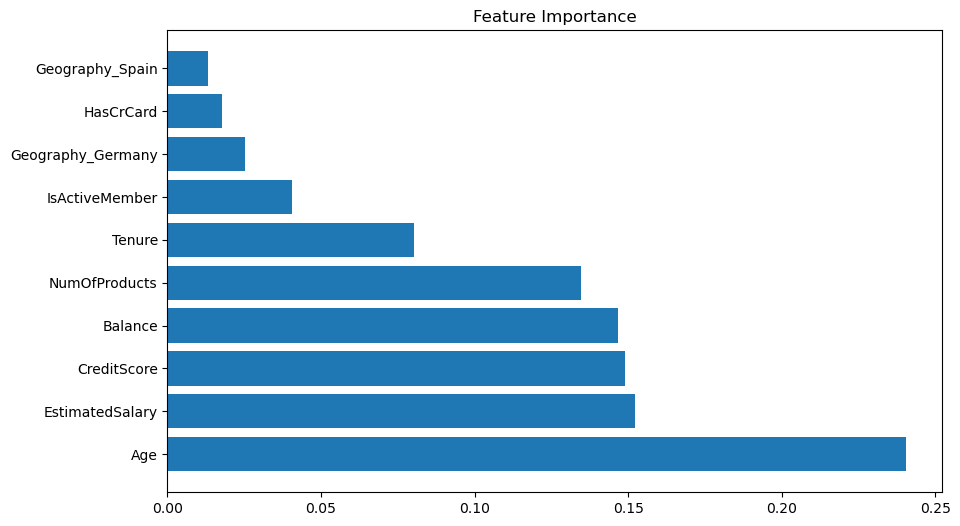

In [16]:
importance=model.feature_importances_
indices=np.argsort(importance) [::-1]
names=[features[i] for i in indices]
plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.barh(range(x.shape[1]),importance[indices])
plt.yticks(range(x.shape[1]),names)
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log_reg=log_reg.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred_log_reg))
print("Class Report:",classification_report(y_test,y_pred_log_reg))
print("confusion matrix:",confusion_matrix(y_test,y_pred_log_reg))


Accuracy: 0.8185
Class Report:               precision    recall  f1-score   support

           0       0.83      0.97      0.90      1607
           1       0.62      0.20      0.30       393

    accuracy                           0.82      2000
   macro avg       0.73      0.58      0.60      2000
weighted avg       0.79      0.82      0.78      2000

confusion matrix: [[1560   47]
 [ 316   77]]


In [21]:
from sklearn.svm import SVC

svm_model= SVC(kernel='linear',random_state=42)
svm_model.fit(X_train,y_train)               

SVC(kernel='linear', random_state=42)

In [23]:
y_pred_svm=svm_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred_svm))
print("Class Report:",classification_report(y_test,y_pred_svm))
print("confusion matrix:",confusion_matrix(y_test,y_pred_svm))


Accuracy: 0.8035
Class Report:               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000

confusion matrix: [[1607    0]
 [ 393    0]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
